# Control PI-D ---$D$ (derivada) solo de $y$---

Teniendo en cuenta los problemas que aparecen cuando sacamos la derivada de una función escalón, que suele aparecer en los cambios de referencia, vamos a remplazar el controlador PID usual:
$$u(t) = k_pe(t)+ k_i\int_0^te(\tau)d\tau+ k_d\dfrac{d\,e(t)}{dt}$$
donde $e(t)=r(t)-y(t)$. La expresión, en términos de funciones de tranasferencia se puede escribir como
$$u(s) = \left[k_p + k_i/s+ k_d\,s\right] \,(r(s) - y(s)).$$

Teniendo en cuenta que las funciones de referencia $r(t)$ suelen variar lentamente pero sufrir cambios súbitos cuya derivada puede ser muy grande, se usa con frecuencia un esquema donde las derivadas solo se sacan a la salida del proceso $y(t)$. Es decir,  
$$u(t) = k_pe(t)+ k_i\int_0^te(\tau)d\tau+ k_d\dfrac{d\,y(t)}{dt}.$$

Adicionalmente, para garantizar la *realizabilidad* de la componente diferencial, que resulta en ganancias muy grandes a alta frecuencia, se suele incluir un filtro pasabajos en la componente diferencial. Es ese caso, la expresión para la variable de entrada a la planta $P$ queda:
$$u(s) = \left[k_p + \dfrac{k_i}{s}\right] \,(r(s) - y(s))+\dfrac{k_ds}{T_Fs+1}y(s).$$
donde $T_F$ es una constante de tiempo del filtro pasabajos.

La última ecuación se puede expandir:
$$u(s) = \left[k_p + \dfrac{k_i}{s}\right] \,r(s) -\left[k_p + \dfrac{k_i}{s}+\dfrac{k_ds}{T_Fs+1}\right] \,y(s).$$

La última expresión se puede resumir diciendo que hay dos funciones de transferencia diferentes para la las dos señales que afectan el control ($r(s)$ y $y(t)$). Esto se puede resumir así:
$$u(s) = K_r(s)\,r(s) - K_y(s)\,y(s).$$
En un diagrama de bloques, esta relación se puede representar como indica la figura siguiente:

![Controlador de dos parámetros](c2p_k1_k2-1.png)

Basados en el diagrama, es fácil ver que la función de transferencia de lazo cerrado de este sistema es:
$$T(s) = K_r(s) \dfrac{P(s)}{1 + P(s)\, K_y(s)}$$

Vamos a aplicar este esquema a la planta siguiente:

$$P(s) = \dfrac{1}{(s+1) (1.25s+1) (4s+1)}$$

Inicialmente, haremos un diseño basado en las reglas de Ziegler y Nichols; para ello calculamos los márgenes de estabilidad



In [10]:
include("ControlUN.jl")
# diseño Ziegler-Nichols
# Modelo ss de componente PI
s = tf("s")
P = 1/((s+1) * (1.25s+1) * (4s+1))
wgm1, gm1, wpm1, pm1 = margin(P)
# Ziegler-Nichols
k_p = 0.45gm1[1]
Tcr = 2π/wgm1[1]
T_i = 0.83Tcr
k_i = k_p / T_i
T_d = 0.125Tcr
k_d = k_p * T_d
# Constante de tiempo del filtro la escogemos como Td/10
T_f = T_d/10
# Controlador Ziegler Nichols
Kr = k_p + k_i/s
display(Kr)
Ky = k_p + k_i/s+ k_d*s/(T_f*s + 1)



TransferFunction{Continuous, ControlSystemsBase.SisoRational{Float64}}
5.3184s + 1.1405
----------------
    1.0000s

Continuous-time transfer function model

TransferFunction{Continuous, ControlSystemsBase.SisoRational{Float64}}
4.1087s^2 + 5.3985s + 1.1405
----------------------------
    0.0702s^2 + 1.0000s

Continuous-time transfer function model

La función de transferencia de lazo cerrado queda:

In [11]:

T = minreal(feedback(P*Ky,1))


TransferFunction{Continuous, ControlSystemsBase.SisoRational{Float64}}
                   11.7004s^2 + 15.3734s + 3.2477
--------------------------------------------------------------------
1.0000s^5 + 16.2886s^4 + 30.4392s^3 + 29.6987s^2 + 18.2211s + 3.2477

Continuous-time transfer function model

Cuyos polos de lazo cerrado son:

In [12]:
pole(T)

5-element Vector{ComplexF64}:
 -14.2990 + 0.0000im
  -1.0385 + 0.0000im
  -0.3420 + 0.8375im
  -0.3420 - 0.8375im
  -0.2672 + 0.0000im

Y la respuesta del sistema controlado ante un escalón es:

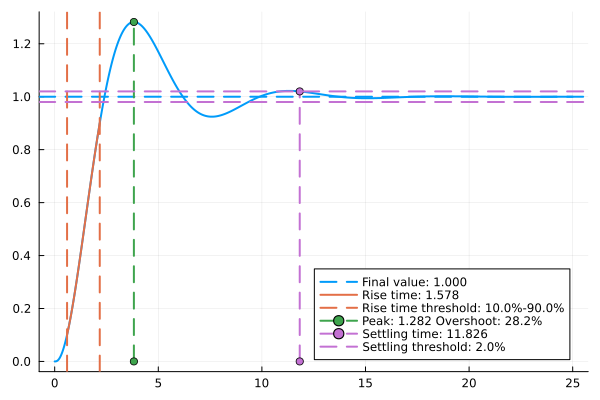

In [13]:
step_plt(T,25)

Vamos a analizar la señal de control para estar seguros de que  este diseño puede funcionar. La función de transferencia $G_{ur}$ de la referencia al control se obtiene como $G_{ur}(s)= T(s)/P(s)$, de la cual obtenemos la respuesta al escalón y calculamos el valor máximo de $u(t)$, 
$$U_{\max}=\max_{t}\{u(t)\}$$

In [14]:
Gur = T / P
max_resp_step(Gur)


58.5022

Un valor bastante alto. Es poco probable que los actuadores sean capaces de dar este valor de salida.

Para estudiar qué puede estar causando este alto valor, grafiquemos la evolución de la señal $u(t)$:

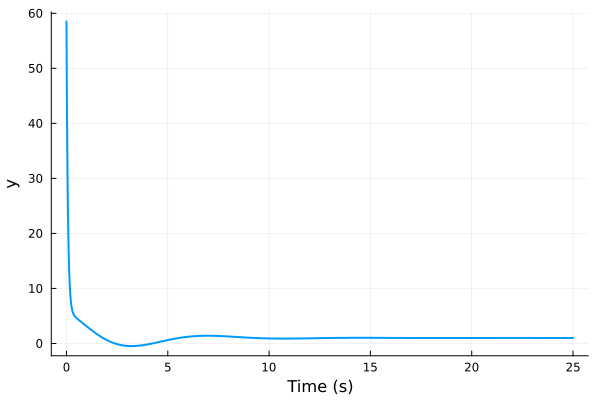

In [15]:
plot(step(Gur,25))

Observamos que el valor muy alto se debe principalmente a la respuesta durante el instante inicial donde la referencia cambió brúscamente.  

## Acción diferencial solo sobre la salida

Cuando se implementa el controlador en la forma de **dos parámetros**, se obtiene :


In [28]:
display(Kr)
display(Ky)

TransferFunction{Continuous, ControlSystemsBase.SisoRational{Float64}}
2.8235s + 0.6085
----------------
    1.0000s

Continuous-time transfer function model

TransferFunction{Continuous, ControlSystemsBase.SisoRational{Float64}}
3.0848s^2 + 2.8345s + 0.6085
----------------------------
    0.0180s^2 + 1.0000s

Continuous-time transfer function model

Usando la forma de dos parámetros, la función $T(s)$ queda:

In [54]:
T = minreal(Kr * feedback(P,Ky))

TransferFunction{Continuous, ControlSystemsBase.SisoRational{Float64}}
                    0.5647s^2 + 31.4939s + 6.7611
----------------------------------------------------------------------
1.0000s^5 + 57.6056s^4 + 115.1389s^3 + 103.9203s^2 + 42.6050s + 6.7611

Continuous-time transfer function model

cuya respuesta al escalón es:

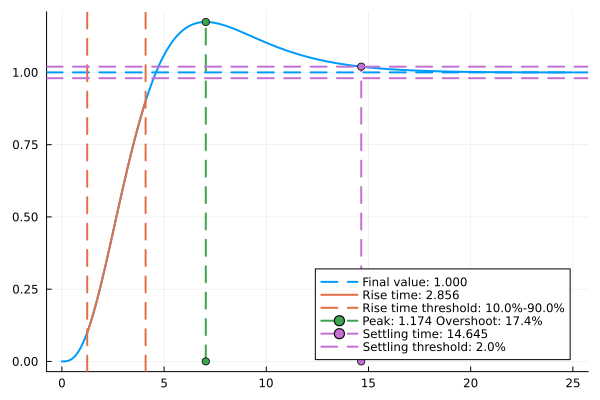

In [30]:
step_plt(T,25)

Se obtiene una respuesta muy parecida al caso anterior. Sin embargo, la señal de control es muy diferente:

In [55]:
Gur = T / P
max_resp_step(Gur)

2.9548

Una gran diferencia con respecto a la implementación anterior. Graficando la entrada,

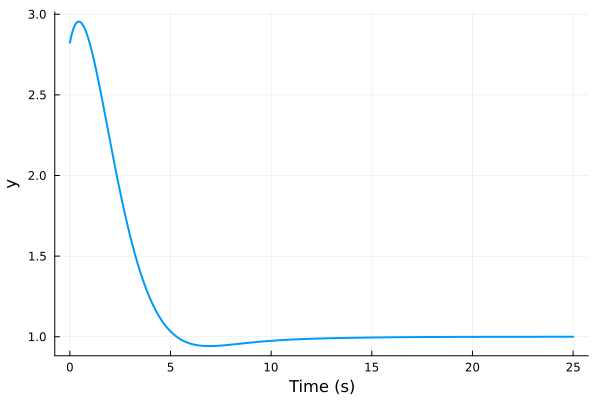

In [32]:
plot(step(Gur,25))

Analicemos otro ejemplo con un diseño un poco mejor, para verificar que el valor alto inicial de $U_{\max}$ ocurre, independientemente del diseño. en la implementación simple del PID.

Para la misma planta anterior, una respuesta mejor se puede obtener con 

In [56]:
k_p = 2.8235
k_i = 0.6085
k_d = 3.034
T_f = 0.018


0.0180

El controlador PID obtenido con esos parámetros es, entonces,

In [57]:
Kr = k_p + k_i/s
Ky = k_p + k_i/s + k_d*s/(T_f*s + 1)


TransferFunction{Continuous, ControlSystemsBase.SisoRational{Float64}}
3.0848s^2 + 2.8345s + 0.6085
----------------------------
    0.0180s^2 + 1.0000s

Continuous-time transfer function model

Usando la implementación normal, con el PID actuando sobre el error, la función de transferencia de lazo cerrado es:

In [58]:
T = minreal(feedback(P*Ky,1))


TransferFunction{Continuous, ControlSystemsBase.SisoRational{Float64}}
                    34.2758s^2 + 31.4939s + 6.7611
----------------------------------------------------------------------
1.0000s^5 + 57.6056s^4 + 115.1389s^3 + 103.9203s^2 + 42.6050s + 6.7611

Continuous-time transfer function model

con polos de lazo cerrado:

In [59]:
pole(T)


5-element Vector{ComplexF64}:
 -55.5669 + 0.0000im
  -0.6310 + 0.5523im
  -0.6310 - 0.5523im
  -0.3883 + 0.1490im
  -0.3883 - 0.1490im

La figura siguiente muestra la respuesta al escalón correspondiente

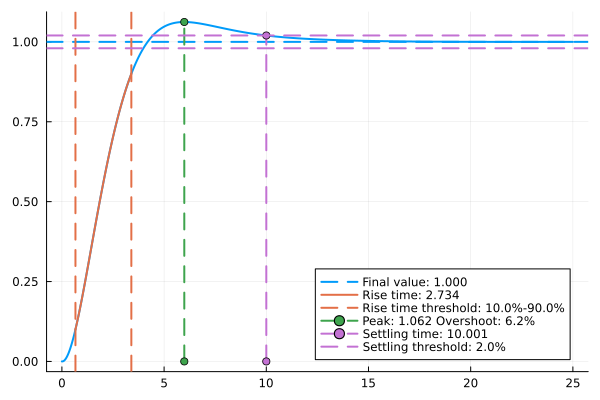

In [37]:
step_plt(T, 25)


A continuación evaluamos el valor de $U_{\max}$:

In [60]:
Gur = T / P
max_resp_step(Gur)

171.3791

El cual es un valor, claramente, muy elevado. Nuevamente, graficamos la respuesta $u(t)$: 

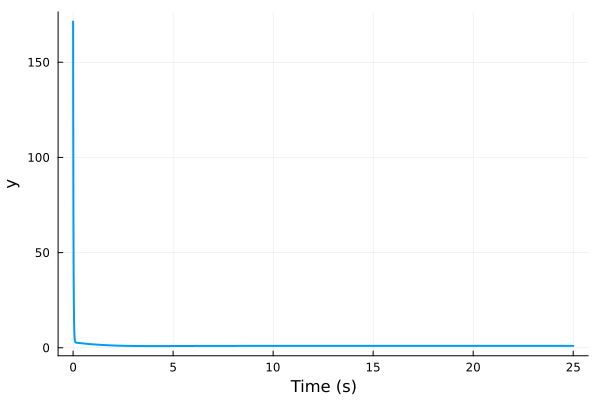

In [39]:
plot(step(Gur,25))


En la misma forma que en el diseño anterior, el altísimo valor de $U_{\max}$ se produce únicamente en el momento inicial cuando cambia la señal de referencia en forma brusca. Todo parece indicar que ese valor se debe especialmente a la derivada de $r(t)$. 

### PID implementado en un controlador 2P

Nuevamente, usaremos una implementación que evita tomar la derivada de la señal de referencia (un controlador de dos parámetros ---o dos grados de libertad). El código correspondiente en Julia es muy similar al anterior:

 - Inicialmente, definimos las dos componentes $K_r$ y $K_y$.


In [61]:
# Usando Controlador de 2 grados de libertad
Kr = pid(k_p, k_i; form=:parallel)
Ky = minreal(Kr + k_d*s/(T_f*s + 1))
display(Kr)
display(Ky)
# Función de transferencia de lazo cerrado
T = minreal(Kr * feedback(P, Ky))


TransferFunction{Continuous, ControlSystemsBase.SisoRational{Float64}}
2.8235s + 0.6085
----------------
    1.0000s

Continuous-time transfer function model

TransferFunction{Continuous, ControlSystemsBase.SisoRational{Float64}}
171.3791s^2 + 157.4696s + 33.8056
---------------------------------
      1.0000s^2 + 55.5556s

Continuous-time transfer function model

TransferFunction{Continuous, ControlSystemsBase.SisoRational{Float64}}
                    0.5647s^2 + 31.4939s + 6.7611
----------------------------------------------------------------------
1.0000s^5 + 57.6056s^4 + 115.1389s^3 + 103.9203s^2 + 42.6050s + 6.7611

Continuous-time transfer function model

Los polos de lazo cerrado son:

In [62]:
pole(T)


5-element Vector{ComplexF64}:
 -55.5669 + 0.0000im
  -0.6310 + 0.5523im
  -0.6310 - 0.5523im
  -0.3883 + 0.1490im
  -0.3883 - 0.1490im

A continuación calculamos la función de transferencia de la referencia a la señal de control $G_{ur}$, para evaluar  el valor máximo de $u(t)$.

In [ ]:
Gur = minreal(T/P)
max_resp_step(Gur)


2.9548

La cual es muy diferente del valor que calculamos arriba de 171.4. Es evidente la ventaja que tiene esta implementación, en la caso de referencias que permanecen constantes la mayor parte del tiempo.

Veamos cómo se comporta la señal de control a lo largo del tiempo:

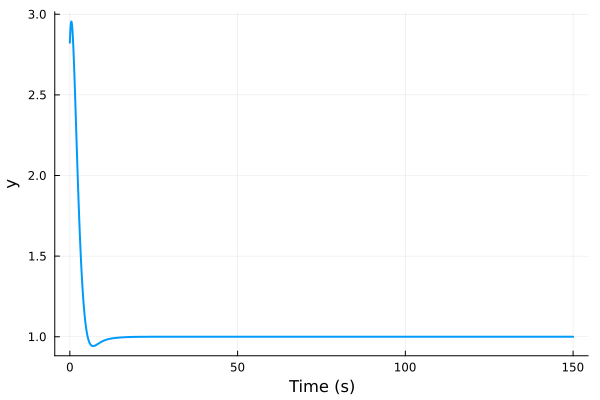

In [43]:
plot(step(Gur))


### Simulación usando variables de estado
Vamos a simular la respuesta del sistema diseñado con base en lo anterior; es decir, la respuesta del controlador de dos parámetros usando modelos de variables de estado y la función `lsim()`. Para ello, debemos obtener modelos de variables de estado de cada componente: $P(s)$, $K_r(s)$ y $K_y(s)$.

Comencemos con el modelo de la planta (por simplicidad,  supondremos que es estríctamente propia ---$D=0$---):
$$\begin{align*}\dot{x} &= A\, x + B\, u\\
y &= C\, x\end{align*}$$

In [63]:
# Modelo en variables de estado
Ps = ss(P)
A, B, C, D = ssdata(Ps)
display(A)
display(B)
display(C)
display(D)
n = size(A)[1];

3×3 Matrix{Float64}:
  0.0000   0.5000   0.0000
  0.0000   0.0000   1.0000
 -0.4000  -1.2500  -2.0500

3×1 Matrix{Float64}:
 0.0000
 0.0000
 0.5000

1×3 Matrix{Float64}:
 0.8000  0.0000  0.0000

1×1 Matrix{Float64}:
 0.0000

La componente **feedforward** del control $K_r$ en variables de estado:
\begin{align*}\dot{x}_r &= A_r\, x_r + B_r\, r\\
u_r &= C_r\, x_r + D_r\, r\end{align*}

In [64]:
Krs = ss(Kr)
Ar, Br, Cr, Dr = ssdata(Krs)
nr = size(Ar)[1];
display(Ar)
display(Br)
display(Cr)
display(Dr)

1×1 Matrix{Float64}:
 0.0000

1×1 Matrix{Float64}:
 1.0000

1×1 Matrix{Float64}:
 0.6085

1×1 Matrix{Float64}:
 2.8235

Por último, la componente **feedback**:
$$
\begin{align*}\dot{x}_y &= A_y\, x_y + B_y\, y\\
    &= A_y\, x_y + B_y\, C\, x\\
u_y &= C_y\, x_y + D_y\, y\\
    &= C_y\, x_y + D_y\, C \, x\end{align*}
$$

In [65]:
Kys = ss(Ky)
Ay, By, Cy, Dy = ssdata(Kys)
ny = size(Ay)[1];
display(Ay)
display(By)
display(Cy)
display(Dy)

2×2 Matrix{Float64}:
 0.0000    0.5000
 0.0000  -55.5556

2×1 Matrix{Float64}:
   0.0000
 128.0000

1×2 Matrix{Float64}:
 0.5282  -73.1530

1×1 Matrix{Float64}:
 171.3791

La señal de control $u(t)$ es $u(t) = U_1(t) - u_2(t)$
$$\begin{align*} u &= -D_y\,C\, x +C_r\,x_r-C_y\,x_y+D_r\,r\\
    &= \begin{bmatrix}-D_y\,C& C_r & -C_y\end{bmatrix}
       \begin{bmatrix} x\\x_r\\x_y \end{bmatrix} + D_r\,r
\end{align*}
$$

Todas estas ecuaciones se pueden combinar en una única ecuación de estado:

$$\begin{bmatrix}\dot{x}\\\dot{x}_r\\\dot{x}_y\end{bmatrix} =
\begin{bmatrix}A& 0 & 0\\0& A_r& 0\\B_yC & 0 & A_y\end{bmatrix}
\begin{bmatrix}x\\ x_r \\ x_y\end{bmatrix} +
\begin{bmatrix}B&0\\ 0& B_r\\0&0\end{bmatrix}
\begin{bmatrix}u\\r\end{bmatrix}$$

$$y = \begin{bmatrix}C& 0 &0\end{bmatrix}\begin{bmatrix}x\\x_r\\x_y\end{bmatrix}$$


In [66]:
A_bar = [A zeros(n,nr) zeros(n,ny);
         zeros(nr,n) Ar zeros(nr,ny);
         By*C zeros(ny,nr) Ay]
B_bar = [B zeros(n,1); zeros(nr,1) Br; zeros(ny,2)]
C_bar = [C zeros(1,nr+ny)]
P_lc = ss(A_bar, B_bar, C_bar, 0)

StateSpace{Continuous, Float64}
A = 
   0.0000   0.5000   0.0000  0.0000  0.0000    0.0000
   0.0000   0.0000   1.0000  0.0000  0.0000    0.0000
  -0.4000  -1.2500  -2.0500  0.0000  0.0000    0.0000
   0.0000   0.0000   0.0000  0.0000  0.0000    0.0000
   0.0000   0.0000   0.0000  0.0000  0.0000    0.5000
 102.4000   0.0000   0.0000  0.0000  0.0000  -55.5556
B = 
 0.0000  0.0000
 0.0000  0.0000
 0.5000  0.0000
 0.0000  1.0000
 0.0000  0.0000
 0.0000  0.0000
C = 
 0.8000  0.0000  0.0000  0.0000  0.0000  0.0000
D = 
 0.0000  0.0000

Continuous-time state-space model


Para la simulación, debemos definir una función que calcule la señal de control $u(t)$ además de especificar la referencia:
$$u(X,t) = \begin{bmatrix}u\\r\end{bmatrix}= 
\begin{bmatrix}-D_y\,C& C_r & -C_y\\ 0& 0&0\end{bmatrix}
\begin{bmatrix}x\\ x_r \\ x_y\end{bmatrix} +
\begin{bmatrix}D_r\\1\end{bmatrix}\,r
$$

En este caso, usaremos una señal de referencia tipo escalón, en $t=0$

In [67]:
F_x = [-Dy*C Cr -Cy; zeros(1,n+nr+ny)]
F_r = [Dr; 1]

u(x,t) = vec(F_x * x .+ F_r .* (t>=0))

u (generic function with 1 method)

Vamos a simular la respuesta, con condición inicial igual a cero.

In [68]:
x0 = zeros(n+nr+ny,1)
t  = 0:0.1:30
y, t, x, uout = lsim(P_lc,u,t,x0=x0)


ControlSystemsBase.SimResult{Matrix{Float64}, StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}, Matrix{Float64}, Matrix{Float64}, StateSpace{Continuous, Float64}}([0.0000 0.0001 … 1.0000 1.0000], 0.0000:0.1000:30.0000, [0.0000 0.0001 … 1.2500 1.2500; 0.0000 0.0066 … 0.0000 0.0000; … ; 0.0000 0.0000 … 32.5310 32.6462; 0.0000 0.0001 … 2.3039 2.3039], [2.8235 2.8784 … 1.0000 1.0001; 1.0000 1.0000 … 1.0000 1.0000], StateSpace{Continuous, Float64}
A = 
   0.0000   0.5000   0.0000  0.0000  0.0000    0.0000
   0.0000   0.0000   1.0000  0.0000  0.0000    0.0000
  -0.4000  -1.2500  -2.0500  0.0000  0.0000    0.0000
   0.0000   0.0000   0.0000  0.0000  0.0000    0.0000
   0.0000   0.0000   0.0000  0.0000  0.0000    0.5000
 102.4000   0.0000   0.0000  0.0000  0.0000  -55.5556
B = 
 0.0000  0.0000
 0.0000  0.0000
 0.5000  0.0000
 0.0000  1.0000
 0.0000  0.0000
 0.0000  0.0000
C = 
 0.8000  0.0000  0.0000  0.0000  0.0000  0.0000
D = 
 0.0000  0.0000

Continuo

El valor máximo de la señal de control es:

In [69]:
max_u = maximum(uout[1,:])


2.9546

Similar al valor obtenido anteriormente.

Con esta señal de control, la respuesta que se obtine es la siguiente:

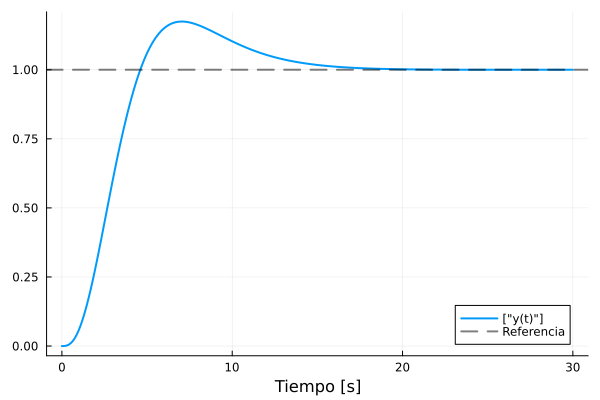

In [70]:
plot(t,y', lab=["y(t)"], xlabel="Tiempo [s]")
hline!([1], lab="Referencia", l=(:black, :dash, 0.5))

Finalmente, graficamos $u(t)$.

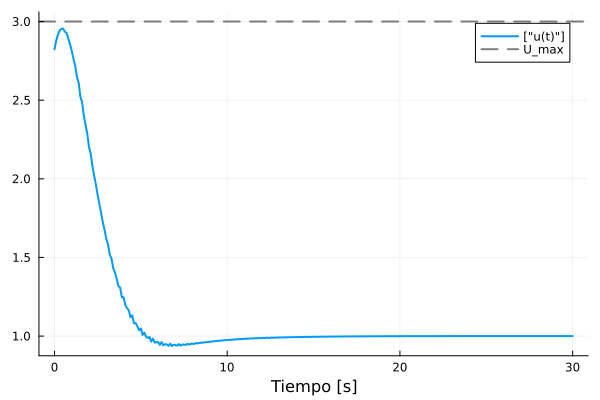

In [72]:
u_max = 3
plot(t, uout[1,:], lab=["u(t)"], xlabel="Tiempo [s]")
hline!([u_max], lab="U_max", l=(:black, :dash, 0.5))